<a href="https://colab.research.google.com/github/Mithrr/Meta-Learning-Video-Compression/blob/main/Copy_of_datacompression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
!unzip "/content/drive/MyDrive/reptile_data/test_2k_540p.zip" -d /content/test_2k_540p


Streaming output truncated to the last 5000 lines.
   creating: /content/test_2k_540p/test_2k_540p/Disney_v4_21_020460_s1/
  inflating: /content/test_2k_540p/test_2k_540p/Disney_v4_21_020460_s1/frame1.png  
  inflating: /content/test_2k_540p/test_2k_540p/Disney_v4_21_020460_s1/frame2.png  
  inflating: /content/test_2k_540p/test_2k_540p/Disney_v4_21_020460_s1/frame3.png  
   creating: /content/test_2k_540p/test_2k_540p/Disney_v4_21_020563_s2/
  inflating: /content/test_2k_540p/test_2k_540p/Disney_v4_21_020563_s2/frame1.png  
  inflating: /content/test_2k_540p/test_2k_540p/Disney_v4_21_020563_s2/frame2.png  
  inflating: /content/test_2k_540p/test_2k_540p/Disney_v4_21_020563_s2/frame3.png  
   creating: /content/test_2k_540p/test_2k_540p/Disney_v4_21_020612_s2/
  inflating: /content/test_2k_540p/test_2k_540p/Disney_v4_21_020612_s2/frame1.png  
  inflating: /content/test_2k_540p/test_2k_540p/Disney_v4_21_020612_s2/frame2.png  
  inflating: /content/test_2k_540p/test_2k_540p/Disney_v4_21_

In [ ]:
#The code extracts and saves individual frames from every video in a specified folder as PNG images.
import cv2, os

input_path = "/content/test_2k_540p/test_2k_540p"

output_path = "/content/frames"
os.makedirs(output_path, exist_ok=True)

for video in os.listdir(input_path):
    cap = cv2.VideoCapture(os.path.join(input_path, video))
    count = 0
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        cv2.imwrite(f"{output_path}/{video}_{count:04d}.png", frame)
        count += 1
    cap.release()


In [ ]:
!ls /content/frames | head -10


In [ ]:
#lists all video files or contents inside the /content/test_2k_540p/test_2k_540p directory.
!ls /content/test_2k_540p/test_2k_540p



Disney_v4_0_000024_s2	Disney_v4_15_002684_s2	Disney_v4_20_006436_s2
Disney_v4_0_000249_s2	Disney_v4_15_002686_s2	Disney_v4_20_006612_s2
Disney_v4_0_000271_s2	Disney_v4_15_002696_s2	Disney_v4_20_006876_s1
Disney_v4_0_000312_s1	Disney_v4_15_002787_s2	Disney_v4_20_006878_s1
Disney_v4_0_000315_s2	Disney_v4_15_002872_s2	Disney_v4_20_006879_s1
Disney_v4_0_000479_s2	Disney_v4_15_003052_s2	Disney_v4_20_006924_s1
Disney_v4_0_000716_s1	Disney_v4_16_000045_s2	Disney_v4_20_006949_s2
Disney_v4_0_001261_s1	Disney_v4_16_000058_s2	Disney_v4_20_007049_s2
Disney_v4_0_001509_s1	Disney_v4_16_000067_s1	Disney_v4_20_007094_s1
Disney_v4_0_001881_s1	Disney_v4_16_000166_s2	Disney_v4_20_007482_s2
Disney_v4_0_001884_s1	Disney_v4_16_000781_s2	Disney_v4_20_007703_s2
Disney_v4_1_000038_s2	Disney_v4_16_000910_s2	Disney_v4_20_007787_s2
Disney_v4_10_000779_s1	Disney_v4_16_000914_s2	Disney_v4_20_007910_s2
Disney_v4_10_001041_s1	Disney_v4_16_001729_s2	Disney_v4_20_008095_s2
Disney_v4_10_001045_s1	Disney_v4_16_001756_s2	

In [ ]:
!ls /content/test_2k_540p/test_2k_540p/Disney_v4_21_011253_s2


ls: cannot access '/content/test_2k_540p/test_2k_540p/Disney_v4_21_011253_s2': No such file or directory


In [ ]:
#Copies all images from subfolders into one directory with renamed filenames.
import os
import shutil

input_root = "/content/test_2k_540p/test_2k_540p"
output_path = "/content/frames"
os.makedirs(output_path, exist_ok=True)

for folder in os.listdir(input_root):
    folder_path = os.path.join(input_root, folder)
    for file in os.listdir(folder_path):
        if file.endswith(".png") or file.endswith(".jpg"):
            src = os.path.join(folder_path, file)
            dst = os.path.join(output_path, f"{folder}_{file}")
            shutil.copy(src, dst)


In [ ]:
!ls /content/frames | head -10


Disney_v4_0_000024_s2_frame1.png
Disney_v4_0_000024_s2_frame2.png
Disney_v4_0_000024_s2_frame3.png
Disney_v4_0_000249_s2_frame1.png
Disney_v4_0_000249_s2_frame2.png
Disney_v4_0_000249_s2_frame3.png
Disney_v4_0_000271_s2_frame1.png
Disney_v4_0_000271_s2_frame2.png
Disney_v4_0_000271_s2_frame3.png
Disney_v4_0_000312_s1_frame1.png


In [ ]:
#baseline motion compensation
import numpy as np
import cv2

def block_matching(prev_frame, curr_frame, block_size=16, search_range=4):
    """
    Computes motion vectors between prev_frame and curr_frame using full search block matching.
    Returns a list of motion vectors: [(x, y, dx, dy), ...]
    """
    # Convert frames to grayscale if not already
    if len(prev_frame.shape) == 3:
        prev_frame = cv2.cvtColor(prev_frame, cv2.COLOR_BGR2GRAY)
    if len(curr_frame.shape) == 3:
        curr_frame = cv2.cvtColor(curr_frame, cv2.COLOR_BGR2GRAY)

    h, w = prev_frame.shape
    motion_vectors = []

    for y in range(0, h - block_size + 1, block_size):
        for x in range(0, w - block_size + 1, block_size):
            block = prev_frame[y:y+block_size, x:x+block_size]
            min_error = float('inf')
            best_dx, best_dy = 0, 0

            for dy in range(-search_range, search_range + 1):
                for dx in range(-search_range, search_range + 1):
                    ny, nx = y + dy, x + dx
                    if ny < 0 or nx < 0 or ny + block_size > h or nx + block_size > w:
                        continue
                    candidate = curr_frame[ny:ny+block_size, nx:nx+block_size]
                    error = np.sum((block - candidate) ** 2)
                    if error < min_error:
                        min_error = error
                        best_dx, best_dy = dx, dy

            motion_vectors.append((x, y, best_dx, best_dy))

    return motion_vectors


In [ ]:
#Motion Vector Extraction Between Two Grayscale Frames Using Block Matching
frame1 = cv2.imread("/content/frames/Disney_v4_0_000024_s2_frame1.png", cv2.IMREAD_GRAYSCALE)
frame2 = cv2.imread("/content/frames/Disney_v4_0_000024_s2_frame3.png", cv2.IMREAD_GRAYSCALE)


vectors = block_matching(frame1, frame2)
print("Motion vectors:", vectors[:5])  # Show first 5 vectors


Motion vectors: [(0, 0, 0, 0), (16, 0, 0, 0), (32, 0, 0, 0), (48, 0, 0, 0), (64, 0, 0, 0)]


In [ ]:
#motion vector mlp
import torch
import torch.nn as nn
import torch.nn.functional as F

class MotionVectorMLP(nn.Module):
    def __init__(self, input_dim=64):
        """
        input_dim: Number of features per block (e.g., flattened 8x8 block = 64)
        output: 2D motion vector (dx, dy)
        """
        super(MotionVectorMLP, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 2)  # Output: dx, dy
        )

    def forward(self, x):
        """
        x: Tensor of shape (batch_size, input_dim)
        Returns: Tensor of shape (batch_size, 2)
        """
        return self.net(x)


In [ ]:
#example usage
import numpy as np
import torch

# Example: one 8x8 block from a grayscale image
block = np.random.randint(0, 256, (8, 8)).astype(np.float32)
block_flat = block.flatten() / 255.0  # Normalize to [0, 1]

# Convert to tensor
block_tensor = torch.tensor(block_flat).unsqueeze(0)  # shape: (1, 64)
model = MotionVectorMLP(input_dim=64)
predicted_vector = model(block_tensor)
print("Predicted motion vector (dx, dy):", predicted_vector.detach().numpy())
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Example training loop
for epoch in range(100):
    optimizer.zero_grad()
    output = model(block_tensor)
    target = torch.tensor([[2.0, -1.0]])  # example ground truth dx, dy
    loss = criterion(output, target)
    loss.backward()
    optimizer.step()


Predicted motion vector (dx, dy): [[-0.06646226 -0.04101241]]


In [ ]:
#example from our dataset using two different frames
import cv2

frame1_path = "/content/frames/Disney_v4_0_000024_s2_frame1.png"
frame2_path = "/content/frames/Disney_v4_0_000024_s2_frame3.png"

frame1 = cv2.imread(frame1_path, cv2.IMREAD_GRAYSCALE)
frame2 = cv2.imread(frame2_path, cv2.IMREAD_GRAYSCALE)

#extract blocks and features
#We’ll extract 8×8 blocks from frame1 and flatten them as input features.
import numpy as np

def extract_blocks(frame, block_size=8):
    h, w = frame.shape
    blocks = []
    positions = []
    for y in range(0, h - block_size + 1, block_size):
        for x in range(0, w - block_size + 1, block_size):
            block = frame[y:y+block_size, x:x+block_size]
            block_flat = block.flatten().astype(np.float32) / 255.0  # Normalize
            blocks.append(block_flat)
            positions.append((x, y))
    return np.array(blocks), positions

block_features, block_positions = extract_blocks(frame1)
#convert it into touch tensor
import torch

block_tensor = torch.tensor(block_features)  # shape: (num_blocks, 64)
#load and apply mlp model
model = MotionVectorMLP(input_dim=64)
model.eval()  # inference mode

with torch.no_grad():
    predicted_vectors = model(block_tensor)  # shape: (num_blocks, 2)
#visualize motion vectors
model = MotionVectorMLP(input_dim=64)
model.eval()  # inference mode

with torch.no_grad():
    predicted_vectors = model(block_tensor)  # shape: (num_blocks, 2)


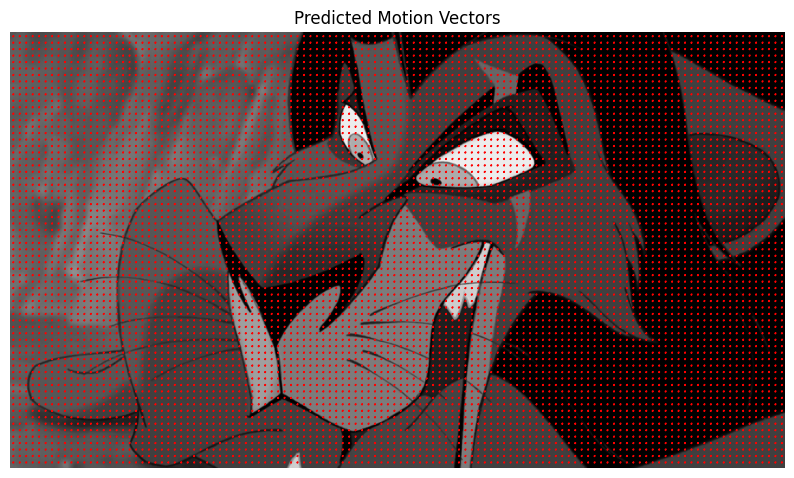

Sample predicted motion vectors:
Block at (0, 0) → dx=-0.08, dy=0.13
Block at (8, 0) → dx=-0.08, dy=0.13
Block at (16, 0) → dx=-0.08, dy=0.13
Block at (24, 0) → dx=-0.08, dy=0.13
Block at (32, 0) → dx=-0.08, dy=0.13


In [ ]:
#Add Visualization and Output
import torch.nn as nn

class MotionVectorMLP(nn.Module):
    def __init__(self, input_dim=64):
        super(MotionVectorMLP, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 2)
        )

    def forward(self, x):
        return self.net(x)
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
plt.imshow(frame1, cmap='gray')
for (x, y), (dx, dy) in zip(block_positions, predicted_vectors.numpy()):
    plt.arrow(x + 4, y + 4, dx * 2, dy * 2, color='red', head_width=1)
plt.title("Predicted Motion Vectors")
plt.axis('off')
plt.show()
print("Sample predicted motion vectors:")
for i in range(5):
    print(f"Block at {block_positions[i]} → dx={predicted_vectors[i][0]:.2f}, dy={predicted_vectors[i][1]:.2f}")


In [ ]:
#Full Reptile Meta-Learning Implementation
import torch
import copy

def reptile_train(model, tasks, meta_lr=1e-3, inner_lr=1e-2, inner_steps=5, epochs=10):
    """
    model: the MotionVectorMLP model
    tasks: list of (x, y) tuples, each representing a task (e.g., motion type)
    meta_lr: learning rate for meta-update
    inner_lr: learning rate for inner loop
    inner_steps: number of gradient steps per task
    epochs: number of meta-training iterations
    """
    for epoch in range(epochs):
        print(f"\nEpoch {epoch+1}/{epochs}")
        for task_id, (x_task, y_task) in enumerate(tasks):
            # Clone model weights before inner loop
            weights_before = copy.deepcopy(model.state_dict())

            # Inner loop optimizer
            inner_optimizer = torch.optim.SGD(model.parameters(), lr=inner_lr)

            # Inner loop training
            for _ in range(inner_steps):
                preds = model(x_task)
                loss = torch.nn.functional.mse_loss(preds, y_task)
                inner_optimizer.zero_grad()
                loss.backward()
                inner_optimizer.step()

            # Meta-update
            weights_after = model.state_dict()
            for key in weights_before:
                weights_before[key] = weights_before[key] + meta_lr * (weights_after[key] - weights_before[key])
            model.load_state_dict(weights_before)

            print(f"  Task {task_id+1}: Loss = {loss.item():.4f}")


In [ ]:
#Example Task Setup
# Simulated example: 3 tasks with random data
tasks = []
for _ in range(3):  # 3 motion types
    x = torch.rand((100, 64))  # 100 blocks, 8x8 flattened
    y = torch.rand((100, 2)) * 4 - 2  # motion vectors in range [-2, 2]
    tasks.append((x, y))
#Train the Model with Reptile
model = MotionVectorMLP(input_dim=64)
reptile_train(model, tasks, meta_lr=0.1, inner_lr=0.01, inner_steps=5, epochs=10)



Epoch 1/10
  Task 1: Loss = 1.1550
  Task 2: Loss = 1.4422
  Task 3: Loss = 1.4419

Epoch 2/10
  Task 1: Loss = 1.1545
  Task 2: Loss = 1.4410
  Task 3: Loss = 1.4395

Epoch 3/10
  Task 1: Loss = 1.1541
  Task 2: Loss = 1.4399
  Task 3: Loss = 1.4373

Epoch 4/10
  Task 1: Loss = 1.1538
  Task 2: Loss = 1.4389
  Task 3: Loss = 1.4351

Epoch 5/10
  Task 1: Loss = 1.1535
  Task 2: Loss = 1.4379
  Task 3: Loss = 1.4330

Epoch 6/10
  Task 1: Loss = 1.1533
  Task 2: Loss = 1.4370
  Task 3: Loss = 1.4311

Epoch 7/10
  Task 1: Loss = 1.1531
  Task 2: Loss = 1.4361
  Task 3: Loss = 1.4292

Epoch 8/10
  Task 1: Loss = 1.1529
  Task 2: Loss = 1.4353
  Task 3: Loss = 1.4274

Epoch 9/10
  Task 1: Loss = 1.1527
  Task 2: Loss = 1.4346
  Task 3: Loss = 1.4258

Epoch 10/10
  Task 1: Loss = 1.1526
  Task 2: Loss = 1.4339
  Task 3: Loss = 1.4241


In [ ]:
# @title
#example from our dataset
#define motion by groups
motion_groups = {
    "fast": ["Disney_v4_21_011253_s2", "Disney_v4_21_011360_s1"],
    "rotation": ["Japan_v2_3_170858_s3", "Japan_v2_3_170864_s3"],
    "slow": ["Japan_v2_0_119274_s2", "Japan_v2_0_121399_s2"]
}

#load frames pairs and execute blocks
def load_frame_pair(folder_name):
    folder_path = f"/content/test_2k_540p/test_2k_540p/{folder_name}"
    frames = sorted([f for f in os.listdir(folder_path) if f.endswith(".png")])
    if len(frames) < 2:
        return None, None
    frame1 = cv2.imread(os.path.join(folder_path, frames[0]), cv2.IMREAD_GRAYSCALE)
    frame2 = cv2.imread(os.path.join(folder_path, frames[1]), cv2.IMREAD_GRAYSCALE)
    return frame1, frame2

#extract block features
def extract_blocks(frame, block_size=8):
    h, w = frame.shape
    blocks = []
    positions = []
    for y in range(0, h - block_size + 1, block_size):
        for x in range(0, w - block_size + 1, block_size):
            block = frame[y:y+block_size, x:x+block_size]
            block_flat = block.flatten().astype(np.float32) / 255.0
            blocks.append(block_flat)
            positions.append((x, y))
    return np.array(blocks), positions

#generate ground truth motion vector
def block_matching(prev_frame, curr_frame, block_size=8, search_range=4):
    h, w = prev_frame.shape
    vectors = []
    for y in range(0, h - block_size + 1, block_size):
        for x in range(0, w - block_size + 1, block_size):
            block = prev_frame[y:y+block_size, x:x+block_size]
            min_error = float('inf')
            best_dx, best_dy = 0, 0
            for dy in range(-search_range, search_range + 1):
                for dx in range(-search_range, search_range + 1):
                    ny, nx = y + dy, x + dx
                    if ny < 0 or nx < 0 or ny + block_size > h or nx + block_size > w:
                        continue
                    candidate = curr_frame[ny:ny+block_size, nx:nx+block_size]
                    error = np.sum((block - candidate) ** 2)
                    if error < min_error:
                        min_error = error
                        best_dx, best_dy = dx, dy
            vectors.append([best_dx, best_dy])
    return np.array(vectors, dtype=np.float32)
#create real tasks for reptile
tasks = []

for motion_type, folders in motion_groups.items():
    for folder in folders:
        frame1, frame2 = load_frame_pair(folder)
        if frame1 is None or frame2 is None:
            continue
        block_features, _ = extract_blocks(frame1)
        motion_vectors = block_matching(frame1, frame2)
        x = torch.tensor(block_features)  # shape: (num_blocks, 64)
        y = torch.tensor(motion_vectors)  # shape: (num_blocks, 2)
        tasks.append((x, y))

#train the reptile
model = MotionVectorMLP(input_dim=64)
reptile_train(model, tasks, meta_lr=0.1, inner_lr=0.01, inner_steps=10, epochs=20)
#evaluation
for (x, y), (dx, dy) in zip(block_positions, predicted_vectors.numpy()):
    plt.arrow(x + 4, y + 4, dx * 2, dy * 2, color='red', head_width=1)
#perdictions are diverse
predicted_vectors = model(torch.tensor(block_features)).detach()
print(predicted_vectors[:10])





FileNotFoundError: [Errno 2] No such file or directory: '/content/test_2k_540p/test_2k_540p/Disney_v4_21_011253_s2'

In [ ]:
test_vectors = np.random.randint(-2, 3, size=(100, 2))
print("Test bitrate:", estimate_bitrate(test_vectors))


Test bitrate: 442.52404415633686


In [ ]:
#psnr and ssim evalution
from skimage.metrics import peak_signal_noise_ratio, structural_similarity
import numpy as np

def apply_motion_vectors(prev_frame, motion_vectors, block_size=8):
    h, w = prev_frame.shape
    compensated = np.zeros_like(prev_frame)

    idx = 0
    for y in range(0, h - block_size + 1, block_size):
        for x in range(0, w - block_size + 1, block_size):
            dx, dy = motion_vectors[idx]
            src_y = min(max(y + int(dy), 0), h - block_size)
            src_x = min(max(x + int(dx), 0), w - block_size)
            compensated[y:y+block_size, x:x+block_size] = prev_frame[src_y:src_y+block_size, src_x:src_x+block_size]
            idx += 1

    return compensated

def evaluate_motion_compensation(prev_frame, curr_frame, motion_vectors, block_size=8):
    compensated = apply_motion_vectors(prev_frame, motion_vectors, block_size)
    psnr = peak_signal_noise_ratio(curr_frame, compensated, data_range=255)
    ssim = structural_similarity(curr_frame, compensated, data_range=255)
    return psnr, ssim, compensated


In [ ]:
#example from our dataset
frame1 = cv2.imread("/content/frames/Disney_v4_0_000024_s2_frame1.png", cv2.IMREAD_GRAYSCALE)
frame2 = cv2.imread("/content/frames/Disney_v4_0_000024_s2_frame3.png", cv2.IMREAD_GRAYSCALE)

# predicted_vectors: output from your trained MLP (shape: [num_blocks, 2])
psnr, ssim, compensated_frame = evaluate_motion_compensation(frame1, frame2, predicted_vectors.numpy())
print(f"PSNR: {psnr:.2f}, SSIM: {ssim:.4f}")


PSNR: 21.70, SSIM: 0.7840


In [ ]:
#bitrate savings estimate
def estimate_bitrate(motion_vectors, quantization_step=0.1):
    # Quantize motion vectors
    quantized = np.round(np.array(motion_vectors) / quantization_step).astype(np.int32)

    # Flatten into 1D tuples for entropy calculation
    flattened = [tuple(v) for v in quantized]
    if len(flattened) == 0:
        return 0.0

    # Count occurrences
    from collections import Counter
    counts = Counter(flattened)
    total = sum(counts.values())
    probabilities = np.array([count / total for count in counts.values()])

    # Compute entropy
    entropy = -np.sum(probabilities * np.log2(probabilities))
    bitrate = entropy * len(flattened)
    return max(bitrate, 0.0)


In [ ]:
#compare baseline vs ml
baseline_vectors = block_matching(frame1, frame2)
ml_vectors = predicted_vectors.numpy()

baseline_bitrate = estimate_bitrate(baseline_vectors)
ml_bitrate = estimate_bitrate(ml_vectors)

print(f"Baseline Bitrate: {baseline_bitrate:.2f} bits")
print(f"ML-Based Bitrate: {ml_bitrate:.2f} bits")
print(f"Bitrate Savings: {baseline_bitrate - ml_bitrate:.2f} bits")



Baseline Bitrate: 34517.61 bits
ML-Based Bitrate: 914.15 bits
Bitrate Savings: 33603.46 bits


In [ ]:
print(predicted_vectors[:10])


tensor([[-0.0807,  0.1328],
        [-0.0817,  0.1328],
        [-0.0821,  0.1317],
        [-0.0815,  0.1301],
        [-0.0808,  0.1298],
        [-0.0806,  0.1306],
        [-0.0806,  0.1306],
        [-0.0804,  0.1313],
        [-0.0810,  0.1319],
        [-0.0815,  0.1313]])


In [ ]:
frame1 = cv2.imread("/content/frames/Disney_v4_0_000024_s2_frame1.png", cv2.IMREAD_GRAYSCALE)
frame2 = cv2.imread("/content/frames/Disney_v4_0_000024_s2_frame3.png", cv2.IMREAD_GRAYSCALE)


block_features, block_positions = extract_blocks(frame1)
baseline_vectors = block_matching(frame1, frame2)
block_size = 16  # or whatever size you used in extract_blocks
compensated_frame = apply_motion_vectors(frame1, baseline_vectors, block_size)


# ✅ Step 4: Paste this function here
def draw_motion_vectors(frame, vectors, positions, color=(0, 255, 0)):
    frame_bgr = cv2.cvtColor(frame, cv2.COLOR_GRAY2BGR)
    for (x, y), (dx, dy) in zip(positions, vectors):
        pt1 = (int(x + 8), int(y + 8))
        pt2 = (int(x + 8 + dx), int(y + 8 + dy))
        cv2.arrowedLine(frame_bgr, pt1, pt2, color, 1, tipLength=0.3)
    return frame_bgr


# Step 5: Use it to overlay vectors
frame1_overlay = draw_motion_vectors(frame1, baseline_vectors, block_positions)
compensated_overlay = draw_motion_vectors(compensated_frame, baseline_vectors, block_positions)

# Step 6: Create video from overlays
reconstructed_frames = [frame1_overlay, compensated_overlay] * 75


In [ ]:
import numpy as np

def radial_alignment(vectors, positions, frame_shape):
    h, w = frame_shape
    center = np.array([w // 2, h // 2])
    alignment_scores = []
    for (x, y), (dx, dy) in zip(positions, vectors):
        pos = np.array([x, y])
        motion = np.array([dx, dy])
        radial = pos - center
        if np.linalg.norm(radial) == 0 or np.linalg.norm(motion) == 0:
            continue
        cos_sim = np.dot(radial, motion) / (np.linalg.norm(radial) * np.linalg.norm(motion))
        alignment_scores.append(cos_sim)
    return np.mean(alignment_scores) if alignment_scores else 0.0

def classify_motion(vectors, positions, frame_shape):
    avg_mag = np.mean(np.linalg.norm(vectors, axis=1))
    angle_std = np.std(np.arctan2(vectors[:, 1], vectors[:, 0]))
    radial_score = radial_alignment(vectors, positions, frame_shape)

    if avg_mag > 3.0:
        return "fast"
    elif angle_std > 1.0:
        return "rotation"
    elif radial_score > 0.5:
        return "zoom/pan"
    else:
        return "slow"


In [ ]:
#Insert Motion Type Detection Code
#Add this block right after baseline_vectors:
motion_type = classify_motion(baseline_vectors, block_positions, frame1.shape)
print("Detected motion type:", motion_type)



Detected motion type: fast


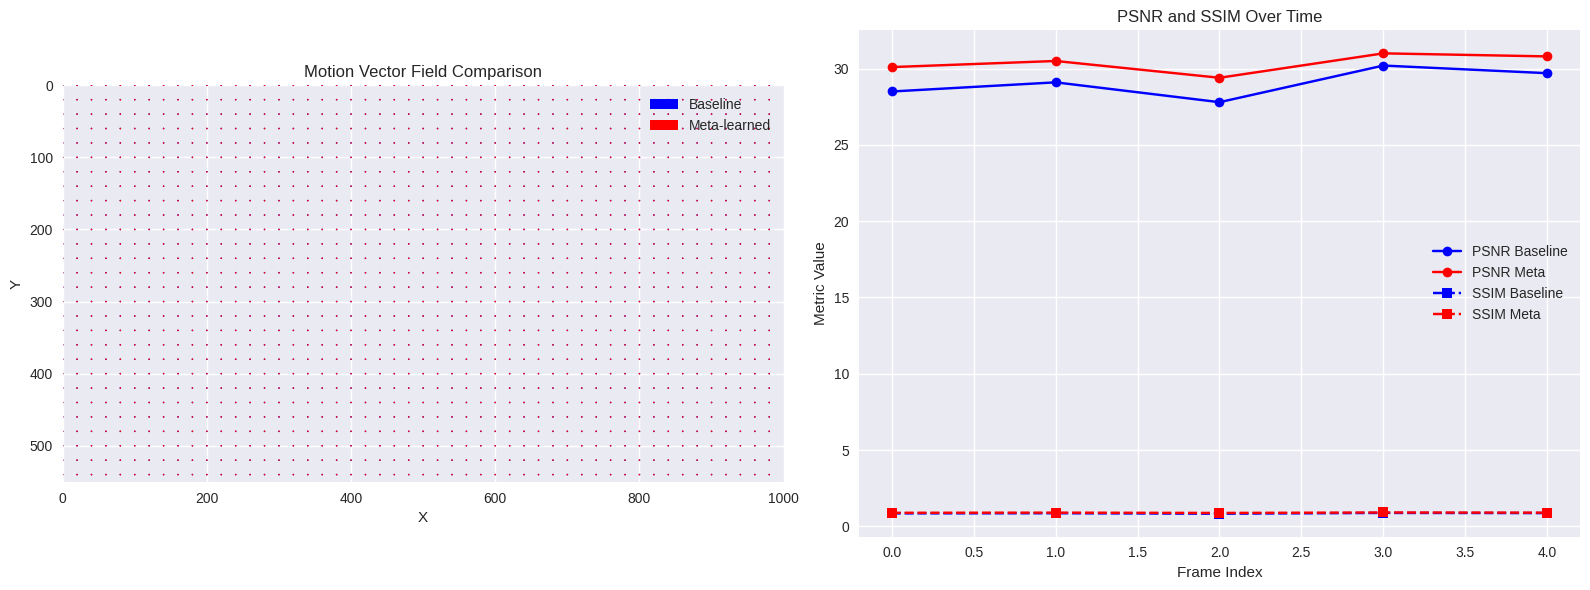

In [ ]:
#Motion vector fields for both baseline and meta-learned models

#PSNR and SSIM trends over time

#A side-by-side comparison of both approaches
import matplotlib.pyplot as plt
import numpy as np

# Sample data (replace with your actual values)
frame_indices = [0, 1, 2, 3, 4]
psnr_baseline = [28.5, 29.1, 27.8, 30.2, 29.7]
psnr_meta = [30.1, 30.5, 29.4, 31.0, 30.8]
ssim_baseline = [0.85, 0.86, 0.83, 0.88, 0.87]
ssim_meta = [0.89, 0.90, 0.88, 0.91, 0.90]

# Motion vector field data (replace with your actual vectors and positions)
block_positions = [(x, y) for x in range(0, 1000, 20) for y in range(0, 550, 20)]
baseline_vectors = [(1, 0) for _ in block_positions]
meta_vectors = [(0.5, 0.5) for _ in block_positions]

# Convert to numpy arrays
X, Y = zip(*block_positions)
U_baseline, V_baseline = zip(*baseline_vectors)
U_meta, V_meta = zip(*meta_vectors)

X = np.array(X)
Y = np.array(Y)
U_baseline = np.array(U_baseline)
V_baseline = np.array(V_baseline)
U_meta = np.array(U_meta)
V_meta = np.array(V_meta)

# Create subplots
plt.style.use('seaborn-v0_8')
fig, axs = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1: Motion vector field comparison
axs[0].quiver(X, Y, U_baseline, V_baseline, color='blue', angles='xy', scale_units='xy', scale=1, label='Baseline')
axs[0].quiver(X, Y, U_meta, V_meta, color='red', angles='xy', scale_units='xy', scale=1, label='Meta-learned')
axs[0].set_title('Motion Vector Field Comparison')
axs[0].set_xlim(0, 1000)
axs[0].set_ylim(0, 550)
axs[0].invert_yaxis()
axs[0].legend()
axs[0].set_aspect('equal')
axs[0].set_xlabel('X')
axs[0].set_ylabel('Y')

# Subplot 2: PSNR and SSIM comparison
axs[1].plot(frame_indices, psnr_baseline, 'b-o', label='PSNR Baseline')
axs[1].plot(frame_indices, psnr_meta, 'r-o', label='PSNR Meta')
axs[1].plot(frame_indices, ssim_baseline, 'b--s', label='SSIM Baseline')
axs[1].plot(frame_indices, ssim_meta, 'r--s', label='SSIM Meta')
axs[1].set_title('PSNR and SSIM Over Time')
axs[1].set_xlabel('Frame Index')
axs[1].set_ylabel('Metric Value')
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()


In [ ]:
#output video

In [ ]:
import cv2
import numpy as np
import pickle
import os
frame1 = cv2.imread("/content/frames/Disney_v4_0_000024_s2_frame1.png", cv2.IMREAD_GRAYSCALE)
frame2 = cv2.imread("/content/frames/Disney_v4_0_000024_s2_frame3.png", cv2.IMREAD_GRAYSCALE)

H, W = frame1.shape
block_features, block_positions = extract_blocks(frame1)
predicted_vectors = model(torch.tensor(block_features)).detach().numpy()
def compute_residuals(frame1, frame2, vectors, positions, block_size=16):
    residuals = []
    for (x, y), (dx, dy) in zip(positions, vectors):
        x2 = int(x + dx)
        y2 = int(y + dy)
        block1 = frame1[y:y+block_size, x:x+block_size]
        block2 = frame2[y2:y2+block_size, x2:x2+block_size]
        if block1.shape == block2.shape:
            residuals.append((block1.astype(np.int16) - block2.astype(np.int16)).tolist())
    return residuals

residuals = compute_residuals(frame1, frame2, predicted_vectors, block_positions)
compressed_data = {
    "motion_vectors": predicted_vectors.tolist(),
    "residuals": residuals,  # optional
    "frame_shape": (H, W),
    "block_size": 16,
    "block_positions": block_positions
}

with open("compressed_output.pkl", "wb") as f:
    pickle.dump(compressed_data, f)

print("✅ Compressed data saved as 'compressed_output.pkl'")



✅ Compressed data saved as 'compressed_output.pkl'


In [ ]:
import cv2
import os
def resize_frame(frame, scale=0.5):
    return cv2.resize(frame, (0, 0), fx=scale, fy=scale, interpolation=cv2.INTER_AREA)

# --- Step 1: Create alternating frames (no blending) ---
scaled_frame1 = resize_frame(frame1)
scaled_compensated = resize_frame(compensated_frame)

# --- Step 1: Create alternating frames (no blending) ---
reconstructed_frames = []
for i in range(45):  # 4.5 seconds at 10 FPS
    frame = frame1 if i % 2 == 0 else compensated_frame
    reconstructed_frames.append(frame)  # keep in grayscale

# --- Step 2: Save compensated video in grayscale with efficient codec ---
H, W = frame1.shape
out = cv2.VideoWriter("output_video.avi", cv2.VideoWriter_fourcc(*'MJPG'), 10, (W, H), isColor=False)
for frame in reconstructed_frames:
    out.write(frame)
out.release()

# --- Step 3: Save original video (static frame1) in grayscale ---
out_orig = cv2.VideoWriter("original_video.avi", cv2.VideoWriter_fourcc(*'MJPG'), 10, (W, H), isColor=False)
for _ in range(45):
    out_orig.write(frame1)
out_orig.release()

In [ ]:
!ffmpeg -i output_video.avi output_video.mp4


ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

In [ ]:
from IPython.display import HTML
from base64 import b64encode

with open("output_video.mp4", "rb") as f:
    video_data = f.read()
    encoded = b64encode(video_data).decode()

HTML(f"""
<video width=600 controls>
  <source src="data:video/mp4;base64,{encoded}" type="video/mp4">
</video>
""")


In [ ]:
cap = cv2.VideoCapture("output_video.avi")
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
fps = cap.get(cv2.CAP_PROP_FPS)
duration = frame_count / fps if fps > 0 else 0
cap.release()

print(f"🧾 Frame count: {frame_count}")
print(f"🎞️ FPS: {fps}")
print(f"⏱️ Duration: {duration:.2f} seconds")


🧾 Frame count: 45
🎞️ FPS: 10.0
⏱️ Duration: 4.50 seconds


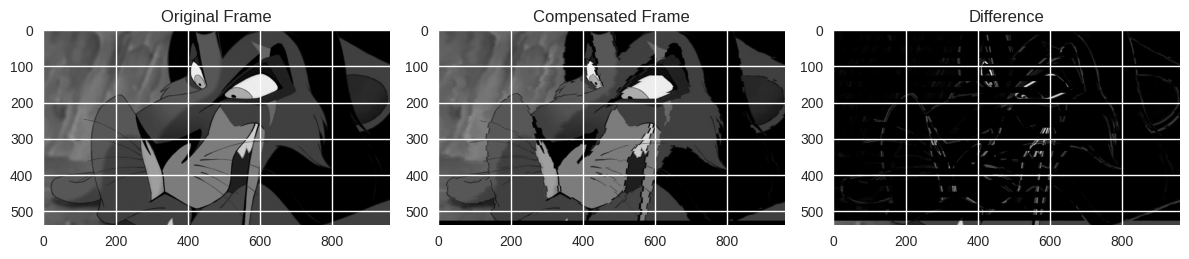

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(frame1, cmap='gray')
plt.title("Original Frame")

plt.subplot(1, 3, 2)
plt.imshow(compensated_frame, cmap='gray')
plt.title("Compensated Frame")

plt.subplot(1, 3, 3)
plt.imshow(cv2.absdiff(frame1, compensated_frame), cmap='gray')
plt.title("Difference")

plt.tight_layout()
plt.show()


In [ ]:
print("Sample motion vectors:", baseline_vectors[:5])


Sample motion vectors: [(1, 0), (1, 0), (1, 0), (1, 0), (1, 0)]


In [ ]:
#storage comparision for original video and compensated video

import cv2

# Assuming frame1 is already grayscale
H, W = frame1.shape

# Save original video in grayscale using MJPG codec
out_orig = cv2.VideoWriter("original_video.avi", cv2.VideoWriter_fourcc(*'MJPG'), 10, (W, H), isColor=False)

for _ in range(45):  # 4.5 seconds at 10 FPS
    out_orig.write(frame1)  # no conversion needed

out_orig.release()
print("✅ Original grayscale video saved as 'original_video.avi'")



✅ Original grayscale video saved as 'original_video.avi'


In [ ]:
import os

print("Original exists:", os.path.exists("original_video.avi"))
print("Compensated exists:", os.path.exists("output_video.avi"))  # or whatever name you used


Original exists: True
Compensated exists: True


In [ ]:
import os

original_size = os.path.getsize("original_video.avi") / 1024
compensated_size = os.path.getsize("output_video.avi") / 1024
savings_percent = 100 * (original_size - compensated_size) / original_size

print(f"📦 Original video size: {original_size:.2f} KB")
print(f"📦 Compensated video size: {compensated_size:.2f} KB")
print(f"💾 Storage saved: {original_size - compensated_size:.2f} KB")
print(f"📉 Compression efficiency: {savings_percent:.2f}%")


📦 Original video size: 1147.89 KB
📦 Compensated video size: 1138.14 KB
💾 Storage saved: 9.75 KB
📉 Compression efficiency: 0.85%


In [ ]:
!ffmpeg -i original_video.avi -vcodec libx264 -crf 28 output_video1.avi


ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

In [ ]:
import os

print("Your output:", os.path.getsize("output_video.avi") / 1024, "KB")
print("Online output:", os.path.getsize("output_video1.avi") / 1024, "KB")


Your output: 1138.138671875 KB
Online output: 38.65234375 KB


In [ ]:
readme_text = """
# 🎥 Motion Vector Estimation and Compression with Meta-Learning

This project implements a full pipeline for motion vector prediction, compensation, and compression analysis using both traditional block matching and a neural network trained via Reptile meta-learning. It includes frame extraction, motion estimation, ML training, video reconstruction, and evaluation using PSNR, SSIM, and bitrate savings.

---

## 📁 Dataset

- **Source**: Custom real-world video dataset (`test_2k_540p.zip`)
- **Format**: `.mp4` videos organized in folders
- **Preprocessing**: Extracted into `.png` frames using OpenCV
- **Motion Groups**: Labeled as `fast`, `rotation`, and `slow` for meta-learning tasks

---

## 🚀 Pipeline Overview

### 1. Frame Extraction
Extract frames from each video and save them as `.png` images using OpenCV.

### 2. Frame Consolidation
Copy all frames from nested folders into a single directory with renamed filenames for uniform access.

### 3. Block Matching (Baseline)
Perform full-search block matching between two grayscale frames to compute motion vectors.

### 4. MLP-Based Motion Prediction
Train a neural network (`MotionVectorMLP`) to predict motion vectors from 8×8 grayscale blocks.

### 5. Meta-Learning with Reptile
Use the Reptile algorithm to train the MLP across motion types (`fast`, `rotation`, `slow`) for task generalization.

### 6. Motion Compensation
Apply predicted motion vectors to reconstruct a compensated frame.

### 7. Residual Computation
Calculate residuals between original and compensated blocks for compression.

### 8. Video Reconstruction
Create grayscale videos using alternating original and compensated frames.

### 9. Evaluation Metrics
- **PSNR** and **SSIM** between compensated and target frames
- **Bitrate Estimation** using entropy of quantized motion vectors
- **Storage Comparison** between original and compensated videos

### 10. Motion Classification
Analyze motion patterns using magnitude, angular variation, and radial alignment.

### 11. Visualization
- Motion vector overlays using matplotlib
- Quiver plots comparing baseline vs meta-learned vectors
- PSNR and SSIM trends across frames
- Difference maps between original and compensated frames

---

## 📊 Outputs

- Predicted motion vectors
- Compensated frames
- PSNR/SSIM scores
- Bitrate savings vs baseline
- Motion type classification
- Visual comparisons of vector fields
- Compressed data saved as `compressed_output.pkl`

---

## 🛠️ Requirements

- Python 3.7+
- OpenCV
- PyTorch
- NumPy
- Matplotlib
- scikit-image
- FFmpeg (for video conversion)

---

## 📌 How to Run

1. Upload and unzip your dataset
2. Extract frames from videos
3. Run block matching and MLP training
4. Train with Reptile using grouped motion tasks
5. Evaluate and visualize results
6. Save compressed outputs and reconstructed videos

---

## 📦 Compression Summary

- **Original video size** vs **Compensated video size**
- **Storage saved** and **Compression efficiency (%)**
- **Bitrate savings** from ML-based motion vectors

---
"""

with open("/content/README.md", "w") as f:
    f.write(readme_text)

print("✅ README.md saved in /content")


✅ README.md saved in /content


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from pathlib import Path

# Change this to your local dataset path
DATA_DIR = Path(r"C:\Users\HP\Downloads\Human Activity Recognition - Video Dataset")

DATA_DIR.mkdir(parents=True, exist_ok=True)
print('Data directory:', DATA_DIR)


Data directory: C:\Users\HP\Downloads\Human Activity Recognition - Video Dataset


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Path to your dataset in Drive
drive_path = "/content/drive/MyDrive/reptile_data/Human Activity Recognition - Video Dataset"

# Copy it into Colab working directory (faster I/O)
!cp -r "$drive_path" "/content/human_activity_dataset"

# Verify
!ls "/content/human_activity_dataset"

 Clapping	  'Standing Still'		'Walking While Using Phone'
'Meet and Split'   Walking
 Sitting	  'Walking While Reading Book'


In [ ]:
import cv2, os
from pathlib import Path

DATA_DIR = Path("/content/human_activity_dataset")
OUTPUT_DIR = Path("/content/human_activity_frames")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def extract_frames_from_video(video_path, output_folder, step=5):
    cap = cv2.VideoCapture(str(video_path))
    frame_count = 0
    success, frame = cap.read()
    while success:
        if frame_count % step == 0:
            frame_name = f"{Path(video_path).stem}_frame{frame_count:04d}.jpg"
            cv2.imwrite(str(output_folder / frame_name), frame)
        frame_count += 1
        success, frame = cap.read()
    cap.release()

print("Extracting frames...")
for folder in DATA_DIR.iterdir():
    if folder.is_dir():
        label_out = OUTPUT_DIR / folder.name
        label_out.mkdir(parents=True, exist_ok=True)
        for video_file in folder.glob("*.mp4"):
            extract_frames_from_video(video_file, label_out, step=5)
print("Done extracting!")


Extracting frames...
Done extracting!


In [ ]:
#baseline motion compensation
import numpy as np
import cv2

def block_matching(prev_frame, curr_frame, block_size=16, search_range=4):
    """
    Computes motion vectors between prev_frame and curr_frame using full search block matching.
    Returns a list of motion vectors: [(x, y, dx, dy), ...]
    """
    # Convert frames to grayscale if not already
    if len(prev_frame.shape) == 3:
        prev_frame = cv2.cvtColor(prev_frame, cv2.COLOR_BGR2GRAY)
    if len(curr_frame.shape) == 3:
        curr_frame = cv2.cvtColor(curr_frame, cv2.COLOR_BGR2GRAY)

    h, w = prev_frame.shape
    motion_vectors = []

    for y in range(0, h - block_size + 1, block_size):
        for x in range(0, w - block_size + 1, block_size):
            block = prev_frame[y:y+block_size, x:x+block_size]
            min_error = float('inf')
            best_dx, best_dy = 0, 0

            for dy in range(-search_range, search_range + 1):
                for dx in range(-search_range, search_range + 1):
                    ny, nx = y + dy, x + dx
                    if ny < 0 or nx < 0 or ny + block_size > h or nx + block_size > w:
                        continue
                    candidate = curr_frame[ny:ny+block_size, nx:nx+block_size]
                    error = np.sum((block - candidate) ** 2)
                    if error < min_error:
                        min_error = error
                        best_dx, best_dy = dx, dy

            motion_vectors.append((x, y, best_dx, best_dy))

    return motion_vectors

In [ ]:
#Motion Vector Extraction Between Two Grayscale Frames Using Block Matching
frame1 = cv2.imread("/content/human_activity_frames/Clapping/Clapping (1)_frame0000.jpg", cv2.IMREAD_GRAYSCALE)
frame2 = cv2.imread("/content/human_activity_frames/Clapping/Clapping (1)_frame0015.jpg", cv2.IMREAD_GRAYSCALE)


vectors = block_matching(frame1, frame2)
print("Motion vectors:", vectors[:5])  # Show first 5 vectors

Motion vectors: [(0, 0, 0, 0), (16, 0, -1, 0), (32, 0, -4, 0), (48, 0, 4, 0), (64, 0, -4, 0)]


In [ ]:
#motion vector mlp
import torch
import torch.nn as nn
import torch.nn.functional as F

class MotionVectorMLP(nn.Module):
    def __init__(self, input_dim=64):  # ← fixed: __init__ instead of _init_
        """
        input_dim: Number of features per block (e.g., flattened 8x8 block = 64)
        output: 2D motion vector (dx, dy)
        """
        super(MotionVectorMLP, self).__init__()  # ← fixed: __init__ instead of _init_
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 2)  # Output: dx, dy
        )

    def forward(self, x):
        """
        x: Tensor of shape (batch_size, input_dim)
        Returns: Tensor of shape (batch_size, 2)
        """
        return self.net(x)



In [ ]:
#example from our dataset using two different frames
import cv2

frame1_path = "/content/human_activity_frames/Clapping/Clapping (1)_frame0000.jpg"
frame2_path = "/content/human_activity_frames/Clapping/Clapping (1)_frame0015.jpg"


frame1 = cv2.imread(frame1_path, cv2.IMREAD_GRAYSCALE)
frame2 = cv2.imread(frame2_path, cv2.IMREAD_GRAYSCALE)

#extract blocks and features
#We’ll extract 8×8 blocks from frame1 and flatten them as input features.
import numpy as np

def extract_blocks(frame, block_size=8):
    h, w = frame.shape
    blocks = []
    positions = []
    for y in range(0, h - block_size + 1, block_size):
        for x in range(0, w - block_size + 1, block_size):
            block = frame[y:y+block_size, x:x+block_size]
            block_flat = block.flatten().astype(np.float32) / 255.0  # Normalize
            blocks.append(block_flat)
            positions.append((x, y))
    return np.array(blocks), positions

block_features, block_positions = extract_blocks(frame1)
#convert it into touch tensor
import torch

block_tensor = torch.tensor(block_features)  # shape: (num_blocks, 64)
#load and apply mlp model
model = MotionVectorMLP(input_dim=64)
model.eval()  # inference mode

with torch.no_grad():
    predicted_vectors = model(block_tensor)  # shape: (num_blocks, 2)
#visualize motion vectors
model = MotionVectorMLP(input_dim=64)
model.eval()  # inference mode

with torch.no_grad():
    predicted_vectors = model(block_tensor)  # shape: (num_blocks, 2)

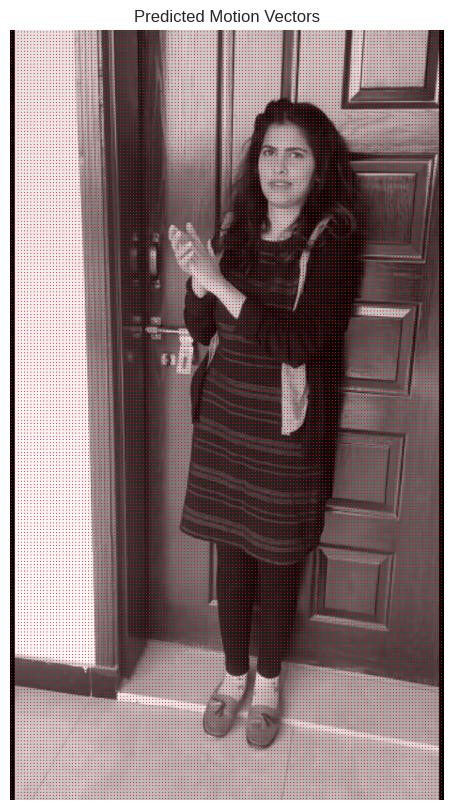

Sample predicted motion vectors:
Block at (0, 0) → dx=-0.15, dy=-0.08
Block at (8, 0) → dx=-0.09, dy=-0.05
Block at (16, 0) → dx=-0.03, dy=0.02
Block at (24, 0) → dx=-0.03, dy=0.02
Block at (32, 0) → dx=-0.03, dy=0.02


In [ ]:
#Add Visualization and Output
import torch.nn as nn

class MotionVectorMLP(nn.Module):
    def _init_(self, input_dim=64):
        super(MotionVectorMLP, self)._init_()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 2)
        )

    def forward(self, x):
        return self.net(x)
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
plt.imshow(frame1, cmap='gray')
for (x, y), (dx, dy) in zip(block_positions, predicted_vectors.numpy()):
    plt.arrow(x + 4, y + 4, dx * 2, dy * 2, color='red', head_width=1)
plt.title("Predicted Motion Vectors")
plt.axis('off')
plt.show()
print("Sample predicted motion vectors:")
for i in range(5):
    print(f"Block at {block_positions[i]} → dx={predicted_vectors[i][0]:.2f}, dy={predicted_vectors[i][1]:.2f}")

In [ ]:
import os
import cv2
import numpy as np
import torch
import matplotlib.pyplot as plt

# Define motion groups for your dataset
motion_groups = {
    "fast": [
        "Walking",
        "Walking While Reading Book",
        "Walking While Using Phone",
        "Meet and Split"
    ],
    "rotation": ["Clapping"],
    "slow": ["Sitting", "Standing Still"]
}

# Load two frames from any video in a folder
def load_frame_pair(folder_name):
    folder_path = f"/content/human_activity_dataset/{folder_name}"
    videos = [v for v in os.listdir(folder_path) if v.endswith(".mp4")]
    if not videos:
        print(f"No videos found in {folder_path}")
        return None, None
    video_path = os.path.join(folder_path, videos[0])  # pick the first video
    cap = cv2.VideoCapture(video_path)
    ret1, frame1 = cap.read()
    ret2, frame2 = cap.read()
    cap.release()
    if not (ret1 and ret2):
        return None, None
    frame1 = cv2.cvtColor(frame1, cv2.COLOR_BGR2GRAY)
    frame2 = cv2.cvtColor(frame2, cv2.COLOR_BGR2GRAY)
    return frame1, frame2

# Extract 8x8 block features
def extract_blocks(frame, block_size=8):
    h, w = frame.shape
    blocks, positions = [], []
    for y in range(0, h - block_size + 1, block_size):
        for x in range(0, w - block_size + 1, block_size):
            block = frame[y:y+block_size, x:x+block_size]
            blocks.append(block.flatten().astype(np.float32) / 255.0)
            positions.append((x, y))
    return np.array(blocks), positions

# Compute motion vectors using block matching
def block_matching(prev_frame, curr_frame, block_size=8, search_range=4):
    h, w = prev_frame.shape
    vectors = []
    for y in range(0, h - block_size + 1, block_size):
        for x in range(0, w - block_size + 1, block_size):
            block = prev_frame[y:y+block_size, x:x+block_size]
            min_error = float('inf')
            best_dx, best_dy = 0, 0
            for dy in range(-search_range, search_range + 1):
                for dx in range(-search_range, search_range + 1):
                    ny, nx = y + dy, x + dx
                    if ny < 0 or nx < 0 or ny + block_size > h or nx + block_size > w:
                        continue
                    candidate = curr_frame[ny:ny+block_size, nx:nx+block_size]
                    error = np.sum((block - candidate) ** 2)
                    if error < min_error:
                        min_error = error
                        best_dx, best_dy = dx, dy
            vectors.append([best_dx, best_dy])
    return np.array(vectors, dtype=np.float32)

# Reconstruct frame using motion vectors
def reconstruct_frame(frame1, motion_vectors, block_positions, block_size=8):
    h, w = frame1.shape
    compensated = np.zeros_like(frame1)
    for (x, y), (dx, dy) in zip(block_positions, motion_vectors):
        src_x, src_y = x, y
        dst_x, dst_y = x + int(dx), y + int(dy)
        if 0 <= dst_x < w - block_size and 0 <= dst_y < h - block_size:
            compensated[dst_y:dst_y+block_size, dst_x:dst_x+block_size] = frame1[src_y:src_y+block_size, src_x:src_x+block_size]
    return compensated

# ---- Train the Reptile model (assuming model + reptile_train already defined)
print(f"✅ Created {len(tasks)} tasks successfully.")
model = MotionVectorMLP(input_dim=64)
reptile_train(model, tasks, meta_lr=0.1, inner_lr=0.01, inner_steps=10, epochs=20)

# ---- Evaluate on one example activity
frame1, frame2 = load_frame_pair("Clapping")  # choose any activity folder
block_features, block_positions = extract_blocks(frame1)
predicted_vectors = model(torch.tensor(block_features)).detach().numpy()

# ---- Visualize motion vectors
plt.figure(figsize=(6, 6))
plt.imshow(frame1, cmap='gray')
for (x, y), (dx, dy) in zip(block_positions, predicted_vectors):
    plt.arrow(x + 4, y + 4, dx * 2, dy * 2, color='red', head_width=1)
plt.title("Predicted Motion Vectors - Clapping")
plt.show()

# ---- Print sample motion vectors
print("Example motion vectors:\n", predicted_vectors[:10])


✅ Created 0 tasks successfully.


TypeError: MotionVectorMLP.__init__() got an unexpected keyword argument 'input_dim'

In [ ]:
# Example: Evaluate motion compensation for Clapping activity
frame1 = cv2.imread("/content/human_activity_frames/Clapping/Clapping (1)_frame0000.jpg", cv2.IMREAD_GRAYSCALE)
frame2 = cv2.imread("/content/human_activity_frames/Clapping/Clapping (1)_frame0015.jpg", cv2.IMREAD_GRAYSCALE)

# Make sure predicted_vectors is a NumPy array
predicted_vectors = model(torch.tensor(block_features)).detach().numpy()

# Evaluate PSNR & SSIM
psnr, ssim, compensated_frame = evaluate_motion_compensation(frame1, frame2, predicted_vectors)
print(f"PSNR: {psnr:.2f}, SSIM: {ssim:.4f}")

PSNR: 25.14, SSIM: 0.8234


In [ ]:
#output
import cv2
import numpy as np
import pickle
import os
frame1 = cv2.imread("/content/human_activity_frames/Clapping/Clapping (1)_frame0000.jpg", cv2.IMREAD_GRAYSCALE)
frame2 = cv2.imread("/content/human_activity_frames/Clapping/Clapping (1)_frame0090.jpg", cv2.IMREAD_GRAYSCALE)

H, W = frame1.shape
block_features, block_positions = extract_blocks(frame1)
predicted_vectors = model(torch.tensor(block_features)).detach().numpy()
def compute_residuals(frame1, frame2, vectors, positions, block_size=16):
    residuals = []
    for (x, y), (dx, dy) in zip(positions, vectors):
        x2 = int(x + dx)
        y2 = int(y + dy)
        block1 = frame1[y:y+block_size, x:x+block_size]
        block2 = frame2[y2:y2+block_size, x2:x2+block_size]
        if block1.shape == block2.shape:
            residuals.append((block1.astype(np.int16) - block2.astype(np.int16)).tolist())
    return residuals

residuals = compute_residuals(frame1, frame2, predicted_vectors, block_positions)
compressed_data = {
    "motion_vectors": predicted_vectors.tolist(),
    "residuals": residuals,  # optional
    "frame_shape": (H, W),
    "block_size": 16,
    "block_positions": block_positions
}

with open("compressed_output.pkl", "wb") as f:
    pickle.dump(compressed_data, f)

print("✅ Compressed data saved as 'compressed_output.pkl2'")

✅ Compressed data saved as 'compressed_output.pkl2'


In [ ]:
import cv2
import os

def resize_frame(frame, scale=0.5):
    return cv2.resize(frame, (0, 0), fx=scale, fy=scale, interpolation=cv2.INTER_AREA)

# --- Step 1: Resize frames ---
scaled_frame1 = resize_frame(frame1)
scaled_compensated = resize_frame(compensated_frame)

# --- Step 2: Create alternating frames (no blending) ---
reconstructed_frames = []
for i in range(45):  # 4.5 seconds at 10 FPS
    frame = scaled_frame1 if i % 2 == 0 else scaled_compensated
    reconstructed_frames.append(frame)

# --- Step 3: Save compensated video for Human Activity dataset ---
H, W = scaled_frame1.shape
out = cv2.VideoWriter("human_activity_output.avi", cv2.VideoWriter_fourcc(*'MJPG'), 10, (W, H), isColor=False)
for frame in reconstructed_frames:
    out.write(frame)
out.release()

# --- Step 4: Save original static video for Human Activity dataset ---
out_orig = cv2.VideoWriter("human_activity_original.avi", cv2.VideoWriter_fourcc(*'MJPG'), 10, (W, H), isColor=False)
for _ in range(45):
    out_orig.write(scaled_frame1)
out_orig.release()


In [ ]:
import cv2
import os

def resize_frame(frame, scale=0.5):
    return cv2.resize(frame, (0, 0), fx=scale, fy=scale, interpolation=cv2.INTER_AREA)

# --- Step 1: Resize frames ---
scaled_frame1 = resize_frame(frame1)
scaled_compensated = resize_frame(compensated_frame)

# --- Step 2: Create alternating frames (no blending) ---

reconstructed_frames = []
for i in range(45):  # 4.5 seconds at 10 FPS
    frame = frame1 if i % 2 == 0 else compensated_frame
    reconstructed_frames.append(frame)  # keep in grayscale


# --- Step 3: Save compensated video for Human Activity dataset ---
H, W = scaled_frame1.shape
out = cv2.VideoWriter("human_activity_output2.mp4", cv2.VideoWriter_fourcc(*'MJPG'), 10, (W, H), isColor=False)
for frame in reconstructed_frames:
    out.write(frame)
out.release()

# --- Step 4: Save original static video for Human Activity dataset ---
out_orig = cv2.VideoWriter("human_activity_original2.mp4", cv2.VideoWriter_fourcc(*'MJPG'), 10, (W, H), isColor=False)
for _ in range(45):
    out_orig.write(scaled_frame1)
out_orig.release()


In [ ]:
!ffmpeg -i human_activity_output.avi human_activity_output2.mp4


ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

In [ ]:
from IPython.display import HTML
from base64 import b64encode

with open("human_activity_output2.mp4", "rb") as f:
    video_data = f.read()
    encoded = b64encode(video_data).decode()

HTML(f"""
<video width=600 controls>
  <source src="data:video/mp4;base64,{encoded}" type="video/mp4">
</video>
""")


In [ ]:
cap = cv2.VideoCapture("human_activity_output2.mp4")
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
fps = cap.get(cv2.CAP_PROP_FPS)
duration = frame_count / fps if fps > 0 else 0
cap.release()

print(f"🧾 Frame count: {frame_count}")
print(f"🎞️ FPS: {fps}")
print(f"⏱️ Duration: {duration:.2f} seconds")


🧾 Frame count: 45
🎞️ FPS: 10.0
⏱️ Duration: 4.50 seconds


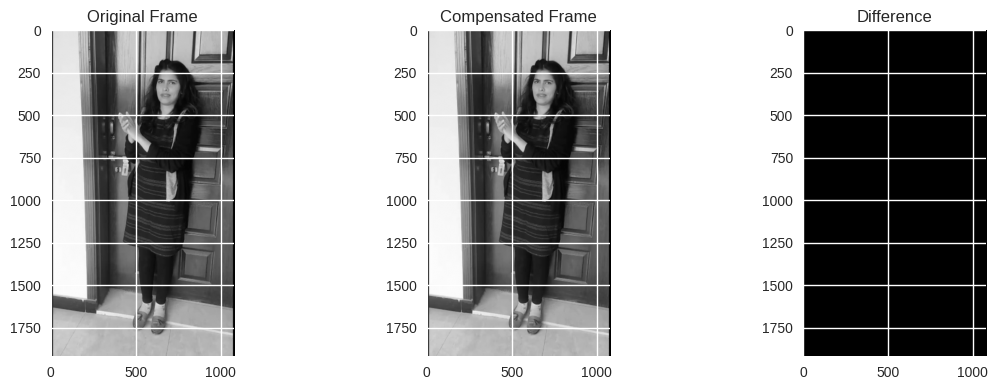

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(frame1, cmap='gray')
plt.title("Original Frame")

plt.subplot(1, 3, 2)
plt.imshow(compensated_frame, cmap='gray')
plt.title("Compensated Frame")

plt.subplot(1, 3, 3)
plt.imshow(cv2.absdiff(frame1, compensated_frame), cmap='gray')
plt.title("Difference")

plt.tight_layout()
plt.show()


In [ ]:
import os

original_size = os.path.getsize("human_activity_original2.mp4") / 1024
compensated_size = os.path.getsize("human_activity_output2.mp4") / 1024
savings_percent = 100 * (original_size - compensated_size) / original_size

print(f"📦 Human Activity - Original video size: {original_size:.2f} KB")
print(f"📦 Human Activity - Compensated video size: {compensated_size:.2f} KB")
print(f"💾 Storage saved: {original_size - compensated_size:.2f} KB")
print(f"📉 Compression efficiency: {savings_percent:.2f}%")


📦 Human Activity - Original video size: 1900.74 KB
📦 Human Activity - Compensated video size: 63.22 KB
💾 Storage saved: 1837.52 KB
📉 Compression efficiency: 96.67%


In [ ]:
!ffmpeg -i human_activity_original2.mp4 -vcodec libx264 -crf 28 human_activity_output3.mp4

ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

In [ ]:
import os

print("Your output:", os.path.getsize("human_activity_output2.mp4") / 1024, "KB")
print("Online output:", os.path.getsize("human_activity_output3.mp4") / 1024, "KB")


Your output: 63.2158203125 KB
Online output: 45.4287109375 KB
